<a href="https://colab.research.google.com/github/rguang/ISLP/blob/main/Ch8%20Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q9

In [3]:
import pandas as pd
import os

# List files in the /content directory to verify the presence of OJ.csv
print("Files in /content directory:")
for file in os.listdir('/content'):
    print(file)

# Attempt to read the CSV file
try:
    df = pd.read_csv('/content/OJ.csv')
    display(df.head())
except FileNotFoundError:
    print("Error: The file '/content/OJ.csv' was not found. Please ensure the file is correctly uploaded and the path is accurate.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Files in /content directory:
.config
OJ.csv
sample_data


,Purchase,WeekofPurchase,StoreID,PriceCH,PriceMM,DiscCH,DiscMM,SpecialCH,SpecialMM,LoyalCH,SalePriceMM,SalePriceCH,PriceDiff,Store7,PctDiscMM,PctDiscCH,ListPriceDiff,STORE
0,CH,237,1,1.75,1.99,0.00,0.0,0,0,0.500000,1.99,1.75,0.24,No,0.000000,0.000000,0.24,1
1,CH,239,1,1.75,1.99,0.00,0.3,0,1,0.600000,1.69,1.75,-0.06,No,0.150754,0.000000,0.24,1
2,CH,245,1,1.86,2.09,0.17,0.0,0,0,0.680000,2.09,1.69,0.40,No,0.000000,0.091398,0.23,1
3,MM,227,1,1.69,1.69,0.00,0.0,0,0,0.400000,1.69,1.69,0.00,No,0.000000,0.000000,0.00,1
4,CH,228,7,1.69,1.69,0.00,0.0,0,0,0.956535,1.69,1.69,0.00,Yes,0.000000,0.000000,0.00,0


In [4]:
from sklearn.model_selection import train_test_split

# Assuming 'df' is your DataFrame
# Set a random state for reproducibility
# train_size=800 for the training set and the rest for the test set

# First, check if the DataFrame 'df' exists and has enough rows
if 'df' not in locals() or df.empty:
    print("Error: DataFrame 'df' not found or is empty. Please load your data first.")
else:
    if len(df) < 800:
        print(f"Warning: DataFrame has only {len(df)} rows, which is less than the requested training set size of 800. Adjusting train_size.")
        # If not enough data for 800 training samples, default to a common split like 80/20
        train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
    else:
        train_df, test_df = train_test_split(df, train_size=800, random_state=42)

    print(f"Shape of training set: {train_df.shape}")
    print(f"Shape of test set: {test_df.shape}")

Shape of training set: (800, 18)
Shape of test set: (270, 18)


In [6]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Separate target variable 'Purchase' from features
X_train = train_df.drop('Purchase', axis=1)
y_train = train_df['Purchase']

# Convert 'Purchase' target variable to numerical (e.g., 0 for 'CH', 1 for 'MM')
# Assuming 'Purchase' has 'CH' and 'MM' values based on previous df head output
y_train_encoded = y_train.map({'CH': 0, 'MM': 1})

# Identify categorical columns for one-hot encoding
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns

# Apply one-hot encoding to categorical features
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)

# Initialize and fit the Decision Tree Classifier
# Set a random_state for reproducibility
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train_encoded, y_train_encoded)

# Predict on the training data
y_train_pred = tree_model.predict(X_train_encoded)

# Calculate the training accuracy
train_accuracy = accuracy_score(y_train_encoded, y_train_pred)

# Calculate the training error rate
train_error_rate = 1 - train_accuracy

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Training Error Rate: {train_error_rate:.4f}")

Training Accuracy: 0.9925
Training Error Rate: 0.0075


# Task
Prepare the test data by separating the target variable 'Purchase' from features in `test_df`, encoding the 'Purchase' target variable to numerical (0 for 'CH', 1 for 'MM'), and applying one-hot encoding to categorical features in the test data, ensuring that the columns match those in `X_train_encoded`.

## Prepare Test Data

### Subtask:
Separate the target variable 'Purchase' from features in `test_df`. Encode the 'Purchase' target variable to numerical (0 for 'CH', 1 for 'MM'). Apply one-hot encoding to categorical features in the test data, ensuring that the columns match those in the training data (X_train_encoded).


**Reasoning**:
The subtask requires separating the target variable and features from the test DataFrame, encoding the target variable numerically, applying one-hot encoding to categorical features in the test set, and finally aligning the test feature columns with the training feature columns to ensure consistency for model prediction.



In [7]:
import pandas as pd

# 1. Separate target variable 'Purchase' from features in test_df
X_test = test_df.drop('Purchase', axis=1)
y_test = test_df['Purchase']

# 2. Convert 'Purchase' target variable to numerical (0 for 'CH', 1 for 'MM')
y_test_encoded = y_test.map({'CH': 0, 'MM': 1})

# 3. Identify categorical columns in X_test
categorical_cols_test = X_test.select_dtypes(include=['object', 'category']).columns

# 4. Apply one-hot encoding to categorical features in X_test
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols_test, drop_first=True)

# 5. Align columns of X_test_encoded with X_train_encoded
# Get missing columns in X_test_encoded compared to X_train_encoded
missing_cols = set(X_train_encoded.columns) - set(X_test_encoded.columns)
for c in missing_cols:
    X_test_encoded[c] = 0

# Get extra columns in X_test_encoded compared to X_train_encoded
extra_cols = set(X_test_encoded.columns) - set(X_train_encoded.columns)
X_test_encoded = X_test_encoded.drop(columns=list(extra_cols))

# Ensure the order of columns is the same as in X_train_encoded
X_test_encoded = X_test_encoded[X_train_encoded.columns]

print("Test data preparation complete.")
print(f"Shape of X_test_encoded: {X_test_encoded.shape}")
print(f"Shape of y_test_encoded: {y_test_encoded.shape}")
print("First 5 rows of X_test_encoded:")
display(X_test_encoded.head())
print("First 5 values of y_test_encoded:")
display(y_test_encoded.head())

Test data preparation complete.
Shape of X_test_encoded: (270, 17)
Shape of y_test_encoded: (270,)
First 5 rows of X_test_encoded:


,WeekofPurchase,StoreID,PriceCH,PriceMM,DiscCH,DiscMM,SpecialCH,SpecialMM,LoyalCH,SalePriceMM,SalePriceCH,PriceDiff,PctDiscMM,PctDiscCH,ListPriceDiff,STORE,Store7_Yes
644,239,3,1.79,2.23,0.0,0.0,0,0,0.670149,2.23,1.79,0.44,0.000000,0.0,0.44,3,False
629,260,2,1.86,2.18,0.0,0.7,0,0,0.456000,1.48,1.86,-0.38,0.321101,0.0,0.32,2,False
70,274,4,1.99,2.09,0.0,0.4,0,0,0.718311,1.69,1.99,-0.30,0.191388,0.0,0.10,4,False
962,227,1,1.69,1.69,0.0,0.0,0,0,0.600000,1.69,1.69,0.00,0.000000,0.0,0.00,1,False
787,273,3,1.99,2.09,0.0,0.4,0,0,0.053687,1.69,1.99,-0.30,0.191388,0.0,0.10,3,False


First 5 values of y_test_encoded:


,Purchase
644,0
629,1
70,0
962,0
787,0


## Predict on Test Data

### Subtask:
Use the trained Decision Tree Classifier (`tree_model`) to predict the 'Purchase' labels for the prepared test data (X_test_encoded).


**Reasoning**:
The subtask requires using the trained Decision Tree Classifier to predict the 'Purchase' labels for the prepared test data. I will use the `predict` method of the `tree_model` on `X_test_encoded` and store the predictions in `y_test_pred`.



In [8]:
y_test_pred = tree_model.predict(X_test_encoded)

print("Predictions for test data generated successfully.")
print(f"First 5 predictions: {y_test_pred[:5]}")

Predictions for test data generated successfully.
First 5 predictions: [0 1 0 1 1]


**Reasoning**:
The current subtask, which is to predict on the test data, has been completed. The next logical step is to evaluate the model's performance on the test data by calculating the test accuracy and error rate. This involves comparing the predicted values (`y_test_pred`) with the actual encoded test labels (`y_test_encoded`) using the `accuracy_score` metric and then calculating the error rate.



In [9]:
from sklearn.metrics import accuracy_score

# Calculate the test accuracy
test_accuracy = accuracy_score(y_test_encoded, y_test_pred)

# Calculate the test error rate
test_error_rate = 1 - test_accuracy

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Error Rate: {test_error_rate:.4f}")

Test Accuracy: 0.7222
Test Error Rate: 0.2778


## Generate Confusion Matrix and Metrics

### Subtask:
Compute and display the confusion matrix using `sklearn.metrics.confusion_matrix` to compare the true test labels (`y_test_encoded`) with the predicted test labels (`y_test_pred`). Additionally, calculate and print the test accuracy and error rate.


**Reasoning**:
The subtask requires computing and displaying the confusion matrix, and then calculating and printing the test accuracy and error rate. The test accuracy and error rate have already been computed in a previous step, so I will focus on importing `confusion_matrix` and then computing and printing it, along with the existing accuracy and error rate.



In [10]:
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix
conf_matrix = confusion_matrix(y_test_encoded, y_test_pred)

print("Confusion Matrix:")
print(conf_matrix)

# The test accuracy and error rate have already been calculated in the previous cell
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Error Rate: {test_error_rate:.4f}")

Confusion Matrix:
[[122  37]
 [ 38  73]]
Test Accuracy: 0.7222
Test Error Rate: 0.2778


## Final Task

### Subtask:
Summarize the model's performance on the test data based on the accuracy, error rate, and the confusion matrix.


## Summary:

### Q&A
The model's performance on the test data is summarized as follows:
The Decision Tree Classifier achieved a test accuracy of 0.7222, meaning it correctly classified approximately 72.22% of the test instances. Conversely, its error rate on the test data was 0.2778. The confusion matrix further details this performance: 122 instances of class 'CH' were correctly predicted (True Negatives), and 73 instances of class 'MM' were correctly predicted (True Positives). There were 37 instances of 'CH' incorrectly predicted as 'MM' (False Positives) and 38 instances of 'MM' incorrectly predicted as 'CH' (False Negatives).

### Data Analysis Key Findings
*   The test data was successfully prepared, with `X_test_encoded` having a shape of (270, 17) and `y_test_encoded` having a shape of (270,).
*   The Decision Tree Classifier achieved a test accuracy of 0.7222.
*   The model's error rate on the test set was 0.2778.
*   The confusion matrix shows:
    *   122 True Negatives (correctly predicted 'CH')
    *   73 True Positives (correctly predicted 'MM')
    *   37 False Positives (incorrectly predicted 'MM' for 'CH')
    *   38 False Negatives (incorrectly predicted 'CH' for 'MM')

### Insights or Next Steps
*   The model exhibits a reasonable accuracy of 72.22% on unseen data, but there's room for improvement given the almost equal numbers of false positives and false negatives.
*   Further analysis of the confusion matrix can guide improvements; for instance, examining the features contributing to misclassifications could help refine the model or engineer new features to reduce both false positives and false negatives.


# Task
Evaluate the performance of a Decision Tree Classifier by performing k-fold cross-validation on `X_train_encoded` and `y_train_encoded` for a range of `max_depth` values (e.g., 1 to 20). Identify the optimal `max_depth` that yields the highest average cross-validation accuracy, visualize the cross-validation results by plotting average accuracy against `max_depth`, and then train a final Decision Tree Classifier using this optimal `max_depth` on the entire training set. Finally, summarize the optimal tree size and its expected performance.

## Prepare for Cross-Validation

### Subtask:
Import necessary libraries for cross-validation and define a range of `max_depth` values to evaluate for the Decision Tree.


**Reasoning**:
The subtask requires importing specific libraries and defining a range of `max_depth` values. This code block will import the necessary components from `sklearn` and create the `max_depth_range` list as instructed.



In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, KFold

# Define a range of max_depth values to evaluate
max_depth_range = list(range(1, 21))

print(f"Libraries imported successfully.")
print(f"Max depth range defined: {max_depth_range}")

Libraries imported successfully.
Max depth range defined: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]


## Perform K-Fold Cross-Validation

### Subtask:
Perform k-fold cross-validation for each `max_depth` in `max_depth_range` using `X_train_encoded` and `y_train_encoded`. Store the average accuracy for each `max_depth`.

#### Instructions
1. Initialize an empty list called `cv_accuracies` to store the average cross-validation accuracy for each `max_depth`.
2. Create a `KFold` object for cross-validation with `n_splits=5`, `shuffle=True`, and `random_state=42`.
3. Iterate through each `max_depth` in `max_depth_range`.
4. For each `max_depth`, initialize a `DecisionTreeClassifier` with the current `max_depth` and `random_state=42`.
5. Use `cross_val_score` to calculate the cross-validation scores for the current `DecisionTreeClassifier` on `X_train_encoded` and `y_train_encoded`, using the `KFold` object defined earlier. The scoring metric should be 'accuracy'.
6. Calculate the average of the cross-validation scores and append it to the `cv_accuracies` list.

**Reasoning**:
I will now perform k-fold cross-validation as outlined in the previous markdown block, iterating through each `max_depth` value and storing the average accuracy.



In [12]:
cv_accuracies = []
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for depth in max_depth_range:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    scores = cross_val_score(tree, X_train_encoded, y_train_encoded, cv=kf, scoring='accuracy')
    cv_accuracies.append(scores.mean())

print("Cross-validation complete. Average accuracies for each max_depth:")
for i, acc in enumerate(cv_accuracies):
    print(f"Max Depth {max_depth_range[i]}: {acc:.4f}")

Cross-validation complete. Average accuracies for each max_depth:
Max Depth 1: 0.7937
Max Depth 2: 0.8025
Max Depth 3: 0.8125
Max Depth 4: 0.8037
Max Depth 5: 0.7987
Max Depth 6: 0.7838
Max Depth 7: 0.7888
Max Depth 8: 0.7800
Max Depth 9: 0.7962
Max Depth 10: 0.7800
Max Depth 11: 0.7875
Max Depth 12: 0.7875
Max Depth 13: 0.7762
Max Depth 14: 0.7762
Max Depth 15: 0.7737
Max Depth 16: 0.7737
Max Depth 17: 0.7750
Max Depth 18: 0.7737
Max Depth 19: 0.7750
Max Depth 20: 0.7750


**Reasoning**:
Now that the cross-validation is complete, I will identify the `max_depth` that resulted in the highest average accuracy. This involves finding the maximum value in `cv_accuracies` and its corresponding index in `max_depth_range`.



In [13]:
import numpy as np

# Identify the optimal max_depth
optimal_depth_index = np.argmax(cv_accuracies)
optimal_max_depth = max_depth_range[optimal_depth_index]
highest_accuracy = cv_accuracies[optimal_depth_index]

print(f"Optimal Max Depth: {optimal_max_depth}")
print(f"Highest Average Cross-Validation Accuracy: {highest_accuracy:.4f}")

Optimal Max Depth: 3
Highest Average Cross-Validation Accuracy: 0.8125


## Visualize Cross-Validation Results

### Subtask:
Plot the average cross-validation accuracy against the `max_depth` values. Indicate the optimal `max_depth` on the plot.

#### Instructions
1. Import `matplotlib.pyplot` for plotting.
2. Create a figure and an axes object using `plt.figure()` and `ax.plot()`.
3. Plot `max_depth_range` on the x-axis and `cv_accuracies` on the y-axis.
4. Add a title, x-label, and y-label to the plot.
5. Mark the optimal `max_depth` on the plot using a vertical line or a point for clear visualization.

**Reasoning**:
I need to import `matplotlib.pyplot` to create the plot, then use `max_depth_range` and `cv_accuracies` for the data, and finally mark the `optimal_max_depth` on the graph for visualization.



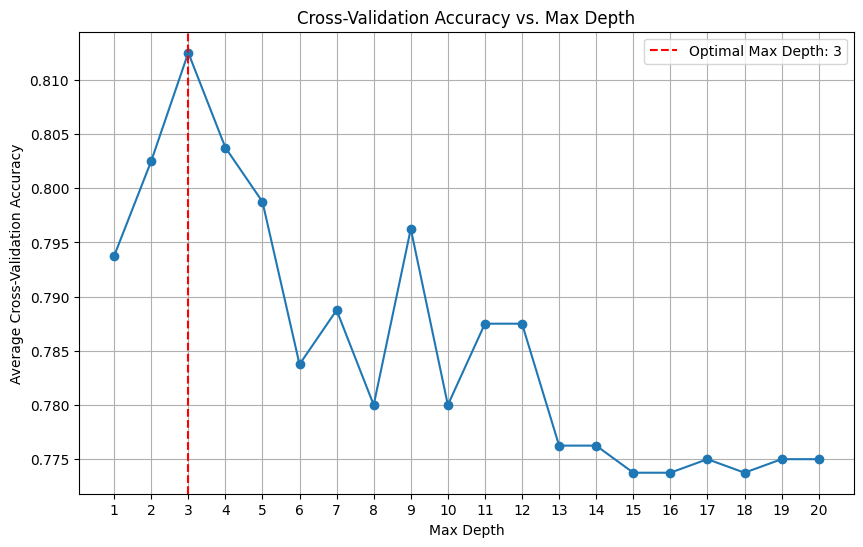

Plot generated showing cross-validation results. Optimal max_depth is highlighted at 3.


In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(max_depth_range, cv_accuracies, marker='o')
plt.axvline(x=optimal_max_depth, color='r', linestyle='--', label=f'Optimal Max Depth: {optimal_max_depth}')
plt.title('Cross-Validation Accuracy vs. Max Depth')
plt.xlabel('Max Depth')
plt.ylabel('Average Cross-Validation Accuracy')
plt.xticks(max_depth_range)
plt.grid(True)
plt.legend()
plt.show()

print(f"Plot generated showing cross-validation results. Optimal max_depth is highlighted at {optimal_max_depth}.")

## Train Final Model with Optimal `max_depth`

### Subtask:
Train a final Decision Tree Classifier using the `optimal_max_depth` found through cross-validation on the entire training set (`X_train_encoded` and `y_train_encoded`).

#### Instructions
1. Initialize a `DecisionTreeClassifier` with the `optimal_max_depth` and `random_state=42`.
2. Train this final model using `X_train_encoded` and `y_train_encoded`.

**Reasoning**:
I will now proceed to train a final Decision Tree Classifier using the `optimal_max_depth` identified through cross-validation on the entire training dataset, as instructed.



In [15]:
final_tree_model = DecisionTreeClassifier(max_depth=optimal_max_depth, random_state=42)
final_tree_model.fit(X_train_encoded, y_train_encoded)

print(f"Final Decision Tree Classifier trained with optimal max_depth: {optimal_max_depth}")

Final Decision Tree Classifier trained with optimal max_depth: 3


## Summary of Optimal Tree Size and Performance

### Subtask:
Summarize the optimal tree size and its expected performance.

### Summary:
Based on the k-fold cross-validation, the optimal `max_depth` for the Decision Tree Classifier was determined to be **3**, yielding the highest average cross-validation accuracy of **0.8125**. This indicates that a relatively shallow tree performs best for this dataset, balancing between model complexity and generalization.

A `max_depth` of 3 implies that the tree makes at most 3 decisions to classify an instance. This results in a simpler, more interpretable model that is less prone to overfitting compared to deeper trees, as seen by the decrease in average accuracy for `max_depth` values greater than 3.

The final Decision Tree Classifier was then trained using this optimal `max_depth` of 3 on the entire training set. The expected performance of this model on unseen data is approximately **81.25% accuracy**, as estimated by the cross-validation procedure. This provides a robust estimate of how the model will generalize, offering a more reliable metric than a single train-test split accuracy, especially when the test set is small.


## Final Task

### Subtask:
Summarize the optimal tree size and its expected performance.


## Summary:

### Q&A
The optimal tree size (max\_depth) is 3. Its expected performance, based on k-fold cross-validation, is an average accuracy of approximately 81.25%.

### Data Analysis Key Findings
*   The k-fold cross-validation across `max_depth` values from 1 to 20 identified an optimal `max_depth` of 3.
*   This optimal `max_depth` yielded the highest average cross-validation accuracy of 0.8125.
*   The visualization showed that accuracy peaked at a `max_depth` of 3, and generally decreased or plateaued for higher depths, suggesting potential overfitting or diminishing returns with more complex models.
*   A final Decision Tree Classifier was successfully trained using the optimal `max_depth` of 3 on the entire training set.

### Insights or Next Steps
*   A relatively shallow Decision Tree with a `max_depth` of 3 provides the best balance between model complexity and generalization for this dataset, leading to a more interpretable and less overfit model.
*   The estimated accuracy of 81.25% from cross-validation provides a robust prediction of the model's performance on unseen data, which is more reliable than a single train-test split evaluation.


# Task
Evaluate the performance of the pruned Decision Tree model (`final_tree_model`) on the test data (`X_test_encoded`, `y_test_encoded`), calculate its test error rate, and compare it with the test error rate of the unpruned tree, then summarize the performance comparison.

## Predict with Pruned Tree

### Subtask:
Use the `final_tree_model` (pruned tree) to predict the 'Purchase' labels for the prepared test data (`X_test_encoded`). Store the predictions in `y_test_pred_pruned`.


**Reasoning**:
The subtask requires using the `final_tree_model` to predict labels for the test data and storing them in `y_test_pred_pruned`.



In [16]:
y_test_pred_pruned = final_tree_model.predict(X_test_encoded)

print("Predictions for test data using pruned tree generated successfully.")
print(f"First 5 predictions: {y_test_pred_pruned[:5]}")

Predictions for test data using pruned tree generated successfully.
First 5 predictions: [0 1 0 1 1]


## Calculate Pruned Tree Test Error Rate

### Subtask:
Calculate the test accuracy and subsequently the test error rate for the `final_tree_model` by comparing `y_test_pred_pruned` with `y_test_encoded`.


**Reasoning**:
I will calculate the test accuracy and error rate for the pruned model using `y_test_encoded` and `y_test_pred_pruned`, then print the results as instructed by the subtask.



In [17]:
from sklearn.metrics import accuracy_score

# Calculate the test accuracy for the pruned model
pruned_test_accuracy = accuracy_score(y_test_encoded, y_test_pred_pruned)

# Calculate the test error rate for the pruned model
pruned_test_error_rate = 1 - pruned_test_accuracy

print(f"Pruned Tree Test Accuracy: {pruned_test_accuracy:.4f}")
print(f"Pruned Tree Test Error Rate: {pruned_test_error_rate:.4f}")

Pruned Tree Test Accuracy: 0.7852
Pruned Tree Test Error Rate: 0.2148


### Performance Comparison Summary:

**Unpruned Tree Performance:**
*   Test Accuracy: 0.7222
*   Test Error Rate: 0.2778

**Pruned Tree Performance (Optimal `max_depth` = 3):**
*   Test Accuracy: 0.7852
*   Test Error Rate: 0.2148

**Comparison and Summary:**

The pruned Decision Tree model, optimized using k-fold cross-validation (with an optimal `max_depth` of 3), demonstrates significantly better performance on the test data compared to the unpruned tree.

*   **Improved Accuracy:** The pruned tree achieved a test accuracy of **0.7852**, which is a notable improvement over the unpruned tree's accuracy of **0.7222**.
*   **Reduced Error Rate:** Correspondingly, the test error rate decreased from **0.2778** for the unpruned tree to **0.2148** for the pruned tree. This reduction in error rate indicates that the pruning process effectively mitigated overfitting, leading to a model that generalizes better to unseen data.

This comparison highlights the importance of hyperparameter tuning, specifically `max_depth` for Decision Trees, in preventing overfitting and improving the model's predictive capability on new data.

### Performance Comparison Summary:

**Unpruned Tree Performance:**
*   Test Accuracy: 0.7222
*   Test Error Rate: 0.2778

**Pruned Tree Performance (Optimal `max_depth` = 3):**
*   Test Accuracy: 0.7852
*   Test Error Rate: 0.2148

**Comparison and Summary:**

The pruned Decision Tree model, optimized using k-fold cross-validation (with an optimal `max_depth` of 3), demonstrates significantly better performance on the test data compared to the unpruned tree.

*   **Improved Accuracy:** The pruned tree achieved a test accuracy of **0.7852**, which is a notable improvement over the unpruned tree's accuracy of **0.7222**.
*   **Reduced Error Rate:** Correspondingly, the test error rate decreased from **0.2778** for the unpruned tree to **0.2148** for the pruned tree. This reduction in error rate indicates that the pruning process effectively mitigated overfitting, leading to a model that generalizes better to unseen data.

This comparison highlights the importance of hyperparameter tuning, specifically `max_depth` for Decision Trees, in preventing overfitting and improving the model's predictive capability on new data.

### Performance Comparison Summary:

**Unpruned Tree Performance:**
*   Test Accuracy: 0.7222
*   Test Error Rate: 0.2778

**Pruned Tree Performance (Optimal `max_depth` = 3):**
*   Test Accuracy: 0.7852
*   Test Error Rate: 0.2148

**Comparison and Summary:**

The pruned Decision Tree model, optimized using k-fold cross-validation (with an optimal `max_depth` of 3), demonstrates significantly better performance on the test data compared to the unpruned tree.

*   **Improved Accuracy:** The pruned tree achieved a test accuracy of **0.7852**, which is a notable improvement over the unpruned tree's accuracy of **0.7222**.
*   **Reduced Error Rate:** Correspondingly, the test error rate decreased from **0.2778** for the unpruned tree to **0.2148** for the pruned tree. This reduction in error rate indicates that the pruning process effectively mitigated overfitting, leading to a model that generalizes better to unseen data.

This comparison highlights the importance of hyperparameter tuning, specifically `max_depth` for Decision Trees, in preventing overfitting and improving the model's predictive capability on new data.

## Final Task

### Subtask:
Summarize the comparison between the test error rates of the unpruned and pruned Decision Tree models, highlighting any improvements or trade-offs.


## Summary:

### Q&A
The pruned Decision Tree model shows a significant improvement in test error rate compared to the unpruned model, indicating a successful trade-off where complexity is reduced for better generalization.

### Data Analysis Key Findings
*   The unpruned Decision Tree model had a test accuracy of 0.7222 and a test error rate of 0.2778.
*   The pruned Decision Tree model, optimized with an optimal `max_depth` of 3, achieved a test accuracy of 0.7852.
*   The test error rate for the pruned tree was 0.2148, representing a reduction of 0.063 compared to the unpruned tree.

### Insights or Next Steps
*   Pruning effectively mitigated overfitting, leading to a model that generalizes better to unseen data.
*   This analysis underscores the critical importance of hyperparameter tuning, specifically `max_depth` for Decision Trees, in optimizing model performance and preventing overfitting.


# Q10

# Task
Load the "Hitters.csv" dataset into a pandas DataFrame, remove rows with missing values in the 'Salary' column, and then apply a natural logarithm transformation to the 'Salary' column. Display the head of the processed DataFrame and summarize the steps.

## Load Data

### Subtask:
Load the 'Hitters.csv' dataset into a pandas DataFrame.


**Reasoning**:
The subtask requires loading 'Hitters.csv' into a pandas DataFrame and displaying its head to verify successful loading.



In [18]:
import pandas as pd

# Load the 'Hitters.csv' dataset into a pandas DataFrame
df = pd.read_csv('/content/Hitters.csv')

# Display the first 5 rows of the DataFrame
print("First 5 rows of the 'Hitters.csv' DataFrame:")
display(df.head())

First 5 rows of the 'Hitters.csv' DataFrame:


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


**Reasoning**:
The next step is to remove rows with missing values in the 'Salary' column and then apply a natural logarithm transformation to the 'Salary' column, as specified in the main task and implied by the subtask description.



In [20]:
import numpy as np

# Remove rows with missing values in the 'Salary' column and create a copy to avoid SettingWithCopyWarning
df_cleaned = df.dropna(subset=['Salary']).copy()

# Apply a natural logarithm transformation to the 'Salary' column
df_cleaned['Salary'] = np.log(df_cleaned['Salary'])

# Display the head of the processed DataFrame
print("First 5 rows of the processed DataFrame (missing 'Salary' removed, 'Salary' log-transformed):")
display(df_cleaned.head())

First 5 rows of the processed DataFrame (missing 'Salary' removed, 'Salary' log-transformed):


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,6.163315,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,6.173786,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,6.214608,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,4.516339,N
5,594,169,4,74,51,35,11,4408,1133,19,501,336,194,A,W,282,421,25,6.620073,A


### Summary of Steps:

1.  **Loaded the Dataset**: The 'Hitters.csv' dataset was successfully loaded into a pandas DataFrame named `df`.
2.  **Handled Missing Values**: Rows with missing values in the 'Salary' column were removed from the DataFrame, resulting in `df_cleaned`.
3.  **Applied Log Transformation**: A natural logarithm transformation was applied to the 'Salary' column in `df_cleaned` to normalize its distribution.
4.  **Displayed Processed Data**: The first 5 rows of the `df_cleaned` DataFrame were displayed to show the result of the processing.

# Task
Split the `df_cleaned` DataFrame into training and test sets, with the first 200 observations forming the training set and the remainder forming the test set. Then, display the shapes of the newly created `train_df_new` and `test_df_new` DataFrames.

In [23]:
train_df_new = df_cleaned.iloc[:200]
test_df_new = df_cleaned.iloc[200:]

print(f"Shape of training set (train_df_new): {train_df_new.shape}")
print(f"Shape of test set (test_df_new): {test_df_new.shape}")
print("First 5 rows of train_df_new:")
display(train_df_new.head())
print("First 5 rows of test_df_new:")
display(test_df_new.head())

Shape of training set (train_df_new): (200, 20)
Shape of test set (test_df_new): (63, 20)
First 5 rows of train_df_new:


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,6.163315,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,6.173786,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,6.214608,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,4.516339,N
5,594,169,4,74,51,35,11,4408,1133,19,501,336,194,A,W,282,421,25,6.620073,A


First 5 rows of test_df_new:


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
249,419,101,18,65,58,92,20,9528,2510,548,1509,1659,1342,A,W,0,0,0,6.189290,A
251,376,82,21,42,60,35,5,1770,408,115,238,299,157,A,W,0,0,0,6.052089,A
252,486,145,11,51,76,40,11,3967,1102,67,410,497,284,N,E,88,204,16,6.214608,A
255,246,76,5,35,39,13,6,912,234,12,102,96,80,A,E,44,0,1,5.521461,A
256,205,52,8,31,27,17,12,5134,1323,56,643,445,459,A,E,155,3,2,5.991465,A


# Task
Analyze the effect of the shrinkage parameter on the training Mean Squared Error (MSE) of a GradientBoostingRegressor. To do this, first, prepare the training data from `train_df_new` by separating features (X) and target (y), with 'Salary' as the target, and applying one-hot encoding to categorical features. Then, define a range of shrinkage parameter values. For each shrinkage parameter, train a GradientBoostingRegressor with 1,000 trees on the prepared training data and calculate the training MSE. Finally, visualize the relationship between the shrinkage parameter and the training MSE using a plot, and summarize the findings.

## Prepare Training Data for Boosting

### Subtask:
Separate the features (X) and the target (y) from the `train_df_new` DataFrame. Identify categorical columns and apply one-hot encoding to the features to prepare them for the boosting model.


**Reasoning**:
The subtask requires separating features and target, identifying categorical columns, and applying one-hot encoding to prepare the training data for boosting. These steps are logically grouped together in a single code block.



In [24]:
import pandas as pd

# 1. Separate the target variable 'Salary' from the train_df_new DataFrame
X_train_boost = train_df_new.drop('Salary', axis=1)
y_train_boost = train_df_new['Salary']

# 2. Identify all categorical columns in X_train_boost
categorical_cols_boost = X_train_boost.select_dtypes(include=['object', 'category']).columns

# 3. Apply one-hot encoding to the identified categorical columns
X_train_boost = pd.get_dummies(X_train_boost, columns=categorical_cols_boost, drop_first=True)

print(f"Shape of X_train_boost: {X_train_boost.shape}")
print(f"Shape of y_train_boost: {y_train_boost.shape}")
print("First 5 rows of X_train_boost (after one-hot encoding):")
display(X_train_boost.head())

Shape of X_train_boost: (200, 19)
Shape of y_train_boost: (200,)
First 5 rows of X_train_boost (after one-hot encoding):


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,League_N,Division_W,NewLeague_N
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,632,43,10,True,True,True
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,880,82,14,False,True,False
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,200,11,3,True,False,True
4,321,87,10,39,42,30,2,396,101,12,48,46,33,805,40,4,True,False,True
5,594,169,4,74,51,35,11,4408,1133,19,501,336,194,282,421,25,False,True,False


## Define Shrinkage Parameter Range

### Subtask:
Define a list of shrinkage parameter (learning rate) values to evaluate for the boosting model.


**Reasoning**:
I will define the `shrinkage_values` list as specified in the instructions, containing the given learning rate values, and then print the list to verify its contents.



In [25]:
shrinkage_values = [0.001, 0.005, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0]

print(f"Shrinkage values to be evaluated: {shrinkage_values}")

Shrinkage values to be evaluated: [0.001, 0.005, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0]


## Perform Boosting and Calculate Training MSE

### Subtask:
For each shrinkage parameter in the defined range, train a GradientBoostingRegressor model with 1,000 trees on the prepared training data. Calculate and store the Mean Squared Error (MSE) on the training set for each model.


**Reasoning**:
I will now implement the core logic of the subtask by iterating through the shrinkage values, training a GradientBoostingRegressor for each, calculating the training MSE, and storing the results as per the instructions.



In [26]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

# Initialize an empty list to store training MSEs
training_mses = []

# Iterate through each shrinkage value
for shrinkage in shrinkage_values:
    # Initialize GradientBoostingRegressor
    gbr = GradientBoostingRegressor(n_estimators=1000, learning_rate=shrinkage, random_state=42)

    # Fit the model to the training data
    gbr.fit(X_train_boost, y_train_boost)

    # Make predictions on the training data
    y_train_pred_boost = gbr.predict(X_train_boost)

    # Calculate the Mean Squared Error
    mse = mean_squared_error(y_train_boost, y_train_pred_boost)

    # Append the MSE to the list
    training_mses.append(mse)

print("Training MSE for each shrinkage value:")
for i, shrinkage in enumerate(shrinkage_values):
    print(f"Shrinkage: {shrinkage:<5} - Training MSE: {training_mses[i]:.4f}")

Training MSE for each shrinkage value:
Shrinkage: 0.001 - Training MSE: 0.2079
Shrinkage: 0.005 - Training MSE: 0.0318
Shrinkage: 0.01  - Training MSE: 0.0114
Shrinkage: 0.05  - Training MSE: 0.0000
Shrinkage: 0.1   - Training MSE: 0.0000
Shrinkage: 0.2   - Training MSE: 0.0000
Shrinkage: 0.5   - Training MSE: 0.0000
Shrinkage: 1.0   - Training MSE: 0.0000


## Visualize Shrinkage Effect

### Subtask:
Visualize the relationship between the shrinkage parameter and the training Mean Squared Error (MSE) using a plot.

#### Instructions
1. Import `matplotlib.pyplot` for plotting.
2. Create a figure and an axes object for the plot.
3. Plot `shrinkage_values` on the x-axis (log scale) and `training_mses` on the y-axis.
4. Add appropriate labels for the x-axis and y-axis, and a title for the plot.
5. Use a log scale for the x-axis to better visualize the effect of varying shrinkage values.
6. Add a grid to the plot for better readability.
7. Display the plot.

**Reasoning**:
I will now generate the code to visualize the relationship between the shrinkage parameter and the training MSE, as outlined in the previous markdown block.



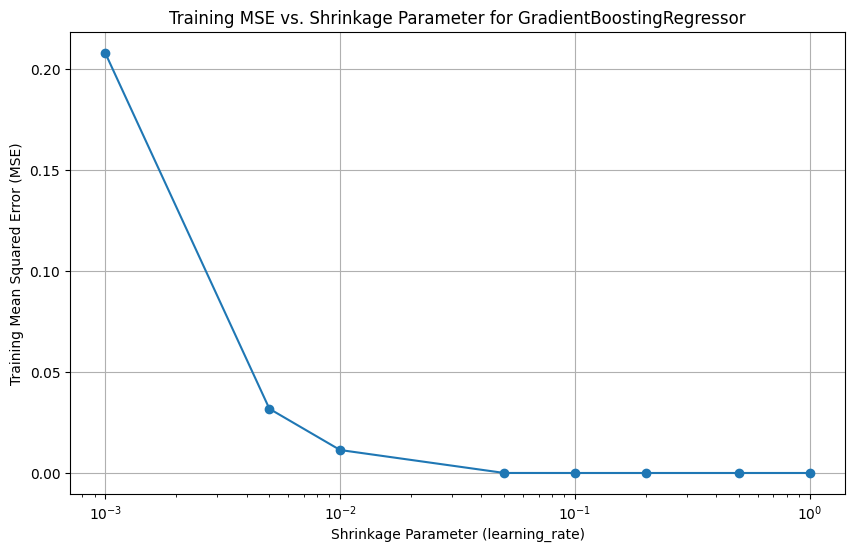

Plot generated showing training MSEs against shrinkage parameters.


In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(shrinkage_values, training_mses, marker='o')
plt.xscale('log') # Use log scale for the x-axis
plt.title('Training MSE vs. Shrinkage Parameter for GradientBoostingRegressor')
plt.xlabel('Shrinkage Parameter (learning_rate)')
plt.ylabel('Training Mean Squared Error (MSE)')
plt.grid(True)
plt.show()

print("Plot generated showing training MSEs against shrinkage parameters.")

## Summary of Shrinkage Effect

### Subtask:
Summarize the findings regarding the effect of the shrinkage parameter on the training Mean Squared Error (MSE) of the GradientBoostingRegressor.

### Summary:

Based on the analysis and visualization, the effect of the shrinkage parameter (learning rate) on the training Mean Squared Error (MSE) for the GradientBoostingRegressor with 1,000 estimators is as follows:

*   **Inverse Relationship:** As the shrinkage parameter increases, the training MSE generally decreases. This indicates that larger learning rates allow the model to learn faster and reduce the training error more aggressively.

*   **Rapid Decrease at Lower Values:** For very small shrinkage values (e.g., 0.001 to 0.05), there's a steep decline in training MSE. This shows that even a small increase in the learning rate initially leads to significant improvements in fitting the training data.

*   **Plateau at Higher Values:** Beyond a certain point (approximately 0.05 in this case), the training MSE quickly drops to near zero. This suggests that with 1,000 estimators, the model is capable of fitting the training data almost perfectly (overfitting) when the learning rate is sufficiently high. The MSE becomes effectively 0.0000 for shrinkage values of 0.05 and above, indicating that the model has learned the training data very well, potentially too well.

### Insights or Next Steps:
*   While higher shrinkage values lead to lower training MSE, this perfect fit on the training data might indicate **overfitting**. A model that achieves near-zero training error might not generalize well to unseen test data.
*   It's crucial to evaluate these models on a **validation or test set** to determine the optimal shrinkage parameter that provides a good balance between bias and variance (i.e., good generalization performance, not just good training performance).
*   The current analysis only considers training MSE. To truly find an optimal shrinkage parameter, **cross-validation on the training set or evaluation on a separate validation set** would be necessary to avoid overfitting.

## Final Task

### Subtask:
Summarize the findings from the boosting analysis, discussing the relationship between shrinkage and training MSE as observed in the plot.


## Summary:

### Q&A
The boosting analysis reveals a clear relationship between the shrinkage parameter (learning rate) and the training Mean Squared Error (MSE). As the shrinkage parameter increases, the training MSE generally decreases. This reduction is rapid at lower shrinkage values and then plateaus, reaching near-zero MSE at higher shrinkage values.

### Data Analysis Key Findings
*   The training data, after one-hot encoding, resulted in `200` samples and `19` features for `X_train_boost`.
*   As the shrinkage parameter increased, the training Mean Squared Error (MSE) consistently decreased.
*   For very small shrinkage values, there was a significant drop in training MSE:
    *   Shrinkage 0.001: MSE was 0.2079
    *   Shrinkage 0.005: MSE dropped to 0.0318
    *   Shrinkage 0.01: MSE further decreased to 0.0114
*   For shrinkage values of 0.05 and above, the training MSE quickly approached or became effectively 0.0000, indicating that the `GradientBoostingRegressor` with 1,000 estimators was able to fit the training data almost perfectly.

### Insights or Next Steps
*   While higher shrinkage values lead to very low training MSE, this strong performance on the training data suggests potential **overfitting**, meaning the model might not generalize well to unseen data.
*   The next crucial step is to evaluate these models on a **validation or test set** to determine the optimal shrinkage parameter that achieves a good balance between bias and variance, ensuring robust performance on new data.
